In [1]:
import pandas as pd
import matplotlib as plt
import seaborn as sns

df=pd.read_csv(r"C:\Users\hp\Downloads\Expense-Tracker-Analysis\data\expenses_clean.csv")
df.head()

,Date,Account,Category,Note,Income/Expense,Amount,Month,Year,Weekday
0,2022-03-02 10:11:00,CUB - online payment,Food,Brownie,Expense,50.0,3,2022,Wednesday
1,2022-03-02 10:11:00,CUB - online payment,Other,To lended people,Expense,300.0,3,2022,Wednesday
2,2022-03-01 19:50:00,CUB - online payment,Food,Dinner,Expense,78.0,3,2022,Tuesday
3,2022-03-01 18:56:00,CUB - online payment,Transportation,Metro,Expense,30.0,3,2022,Tuesday
4,2022-03-01 18:22:00,CUB - online payment,Food,Snacks,Expense,67.0,3,2022,Tuesday


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 273 entries, 0 to 272
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            273 non-null    object 
 1   Account         273 non-null    object 
 2   Category        273 non-null    object 
 3   Note            273 non-null    object 
 4   Income/Expense  273 non-null    object 
 5   Amount          273 non-null    float64
 6   Month           273 non-null    int64  
 7   Year            273 non-null    int64  
 8   Weekday         273 non-null    object 
dtypes: float64(1), int64(2), object(6)
memory usage: 19.3+ KB


In [4]:
df.describe()

,Amount,Month,Year
count,273.000000,273.000000,273.000000
mean,405.169524,6.102564,2021.545788
std,1069.582476,5.158919,0.498814
min,3.000000,1.000000,2021.000000
25%,50.000000,1.000000,2021.000000
50%,125.000000,2.000000,2022.000000
75%,300.000000,12.000000,2022.000000
max,10000.000000,12.000000,2022.000000


In [5]:
income_df=df[df['Income/Expense']=="Income"]
expense_df=df[df['Income/Expense']=="Expense"]

##  Income vs Expense Distribution

This analysis compares total income and total expenses to understand overall financial balance and spending behaviour.


In [6]:
summary=df.groupby("Income/Expense")["Amount"].sum()
summary

Income/Expense
Expense    55857.28
Income     54754.00
Name: Amount, dtype: float64

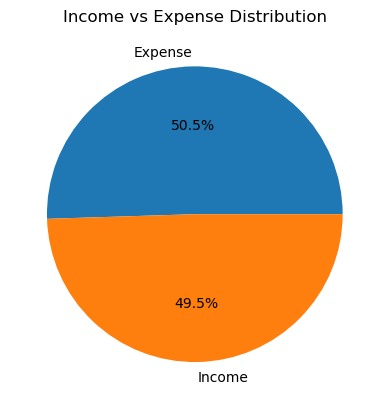

In [10]:
import matplotlib.pyplot as plt

summary.plot(kind="pie", autopct="%1.1f%%")
plt.title("Income vs Expense Distribution")
plt.ylabel("")
plt.savefig(r"C:\Users\hp\Downloads\Expense-Tracker-Analysis\images\income_vs_expense.png")
plt.show()


## Category Wise Expense Analysis

This bar chart shows how expenses are distributed across different categories.
It helps identify which category contributes the most to overall spending.


In [12]:
category_expense=df[df["Income/Expense"]=="Expense"]
category_expense=category_expense.groupby("Category")["Amount"].sum()
category_expense

Category
Apparel              3388.00
Beauty                196.00
Education            1400.00
Food                23338.76
Gift                  115.00
Household           11885.00
Other                5117.00
Self-development      400.00
Social Life           813.72
Transportation       9203.80
Name: Amount, dtype: float64

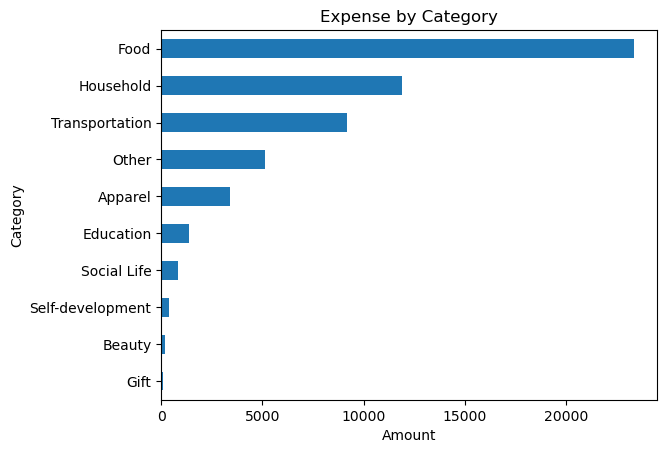

In [13]:
category_expense.sort_values().plot(kind='barh')
plt.title("Expense by Category")
plt.xlabel("Amount")
plt.savefig(r"C:\Users\hp\Downloads\Expense-Tracker-Analysis\images\category_expense.png")
plt.show()

## Monthly Expense Trend

This line chart shows how expenses change over time.
It helps in identifying spending patterns and seasonal variations.


In [14]:
monthly_expense=df[df["Income/Expense"]=="Expense"]
monthly_expense=monthly_expense.groupby("Month")["Amount"].sum()
monthly_expense

Month
1     20679.51
2     15803.65
3       525.00
11     3620.40
12    15228.72
Name: Amount, dtype: float64

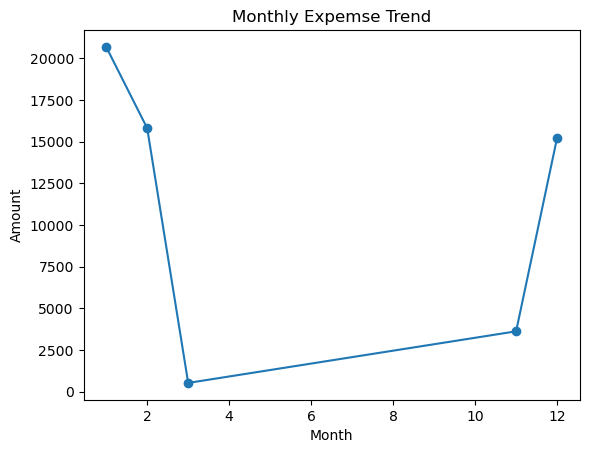

In [15]:
monthly_expense.plot(kind="line",marker="o")
plt.title("Monthly Expemse Trend")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.savefig(r"C:\Users\hp\Downloads\Expense-Tracker-Analysis\images\monthly_expense.png")
plt.show()

## Top 5 Highest Expense Transactions

This chart highlights the highest expense transactions.
It helps identify large spending events.


In [17]:
top_expense=df[df["Income/Expense"]=="Expense"]
top_expense=top_expense.sort_values(by="Amount",ascending=False).head(5)
top_expense

,Date,Account,Category,Note,Income/Expense,Amount,Month,Year,Weekday
223,2021-12-05 12:23:00,CUB - online payment,Household,Rent,Expense,4800.0,12,2021,Sunday
118,2022-01-08 13:38:00,CUB - online payment,Household,Rent,Expense,4580.0,1,2022,Saturday
45,2022-02-08 09:18:00,CUB - online payment,Household,Bean bag,Expense,2099.0,2,2022,Tuesday
222,2021-12-05 18:41:00,CUB - online payment,Apparel,Full hand and a hoodie,Expense,1800.0,12,2021,Sunday
27,2022-02-19 21:35:00,CUB - online payment,Transportation,Bus ticket,Expense,1575.0,2,2022,Saturday


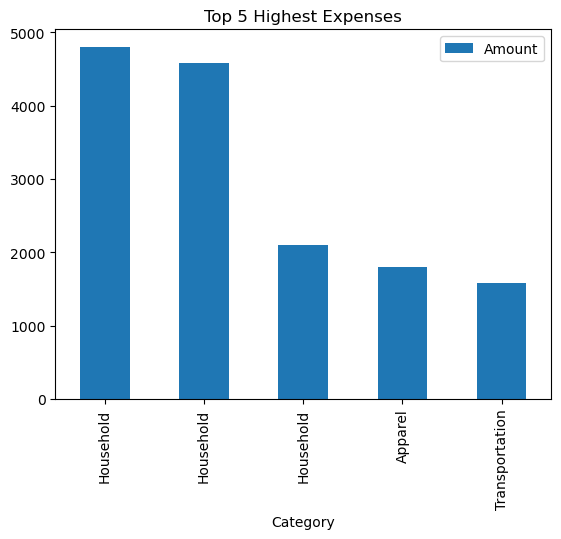

In [18]:
top_expense.plot(kind="bar",x="Category",y="Amount")
plt.title("Top 5 Highest Expenses")
plt.savefig(r"C:\Users\hp\Downloads\Expense-Tracker-Analysis\images\top5_expense.png")
plt.show()

## Expense Distribution

This histogram shows the frequency distribution of expense amounts.
It helps understand common spending ranges.


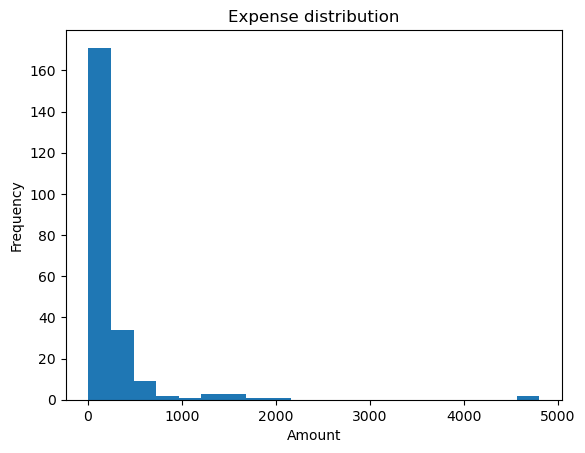

In [19]:
expense_only=df[df["Income/Expense"]=="Expense"]

expense_only["Amount"].plot(kind="hist",bins=20)
plt.title("Expense distribution")
plt.xlabel("Amount")
plt.savefig(r"C:\Users\hp\Downloads\Expense-Tracker-Analysis\images\expense_distribution.png")
plt.show()

## Key Insights

- Majority of transactions are expenses compared to income.
- Food category contributes significantly to overall spending.
- Monthly expense trends show variation across months.
- Most expenses are made through online payment accounts.
- A few high-value transactions contribute heavily to total expenses.
